# Main CW - CIFAR-10 Image Classification

 Objective: Deploy ML Pipeline for image classification task employing a CNN model using TensorFlow and Keras.

### Importing Libraries 
Libraries are imported for model building, data manipulation, and visualization.
TensorFlow and Keras are used for building the neural network model with additional libraries for data handling and visualization.
    

In [13]:
# Importing TensorFlow and keras for CNN building
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn --quiet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Importing other libraries for data handling and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Importing tools for data training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import cifar10


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


### Creating CNN Models
The separate models explore how differences impact accuracy and loss and generalisation. Each model varies in layer depth, dropout rate and learning rate.

In [14]:
def create_model_v1():
    # Basic CNN model with 3 convolutional layers
    model = Sequential([
        
        # First layer with 32 filter
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D((2,2)), #down-sampling
        
        # Second layer with 64 filter
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        
        # Third layer with 128 filter
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
       
        Flatten(), # Flattening the output
        Dense(256, activation='relu'), # Fully connected layer
        Dropout(0.5), # Dropout layer to prevent overfitting by randomly deactivating 30% of neurons during training
        Dense(10, activation='softmax')    # Output layer with 10 classes
    ])

    # Compiling the model with Adam optimizer and categorical crossentropy loss
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [15]:
def create_model_v2():
    # Simpler CNN with 2 convolutional layers
    model = Sequential([

        # First layer with 32 filters
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D((2,2)), 

        # Second layer with 64 filters
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(), 
        Dense(128, activation='relu'),  
        Dropout(0.4),  
        Dense(10, activation='softmax')  
    ])
    # Compiling the model with a reduced learning rate
    model.compile(optimizer=Adam(learning_rate=0.0008), loss='categorical_crossentropy', metrics=['accuracy']) # Lower LR allows finer updates and better convergence for deeper networks
    return model


In [16]:
def create_model_v3():
    # Deeper CNN model with additional conv layer and higher dense units
    model = Sequential([

        # First layer with 32 filters
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
       
        # Second conv layer with 32 filters
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),  # Down-sampling

        # Third layer with 64 filters
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        # Fourth layer with 128 filters
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(), 
        Dense(512, activation='relu'), 
        Dropout(0.3),  
        Dense(10, activation='softmax')  
    ])
    # Compiling the model with lower learning rate for better convergence
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy']) 
    return model


### Dataset Loaded and processed

The CIFAR-10 dataset is loaded and processed. Image data is normalised to a [0, 1] range and labels are one-hot encoded. A validation set is also created using an 80/20 split from the training set.


In [17]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape, X_test.shape)  # (50000, 32, 32, 3) (10000, 32, 32, 3)

# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert class labels to one-hot encoded vectors
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Split the training data into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

(50000, 32, 32, 3) (10000, 32, 32, 3)


In [18]:
def check_images(images, dataset_name):
    """
    Validates each image in the dataset.
    Checks:
    - Is a numpy array
    - Has shape (32, 32, 3)
    - Has no NaN values
    """
    print(f"Checking {dataset_name}...")
    for i, img in enumerate(images):
        if not isinstance(img, np.ndarray):
            print(f"Image {i} is not an array.")
        elif img.shape != (32, 32, 3):
            print(f"Image {i} has incorrect shape: {img.shape}")
        elif np.isnan(img).any():
            print(f"Image {i} contains NaN values.")
    print(f"{dataset_name} check complete.\n")

# Call the function after defining it
check_images(X_train, "Training Set")
check_images(X_test, "Test Set")

Checking Training Set...
Training Set check complete.

Checking Test Set...
Test Set check complete.



### Exploratory Data Analysis (EDA)

The class distribution in the training dataset is visualised to ensure the dataset is balanced. This helps confirm that no class is overrepresented, which could bias the model.


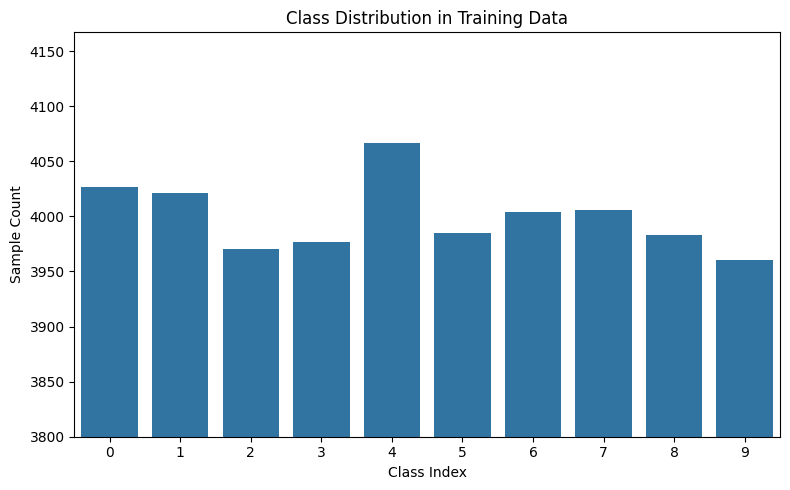

In [19]:
import collections

# Count the number of samples in each class in y_train
label_counts = collections.Counter(np.argmax(y_train, axis=1))

# Plotting the class distribution
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title("Class Distribution in Training Data")
plt.xlabel("Class Index")
plt.ylabel("Sample Count")
plt.ylim(3800, max(label_counts.values()) + 100)  # Set y-axis start at 3000


plt.tight_layout()
plt.show()

### Model Training

All three CNN models are trained with early stopping to prevent overfitting. Training and validation accuracy/loss are monitored across epochs.


In [20]:
# Setup early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train models
model1 = create_model_v1()
history1 = model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stop])

model2 = create_model_v2()
history2 = model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stop])

model3 = create_model_v3()
history3 = model3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stop])

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.3039 - loss: 1.8763 - val_accuracy: 0.5585 - val_loss: 1.2323
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5500 - loss: 1.2546 - val_accuracy: 0.6302 - val_loss: 1.0259
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.6343 - loss: 1.0394 - val_accuracy: 0.6807 - val_loss: 0.8988
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.6853 - loss: 0.9010 - val_accuracy: 0.7074 - val_loss: 0.8347
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.7209 - loss: 0.7963 - val_accuracy: 0.7100 - val_loss: 0.8397
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.7425 - loss: 0.7368 - val_accuracy: 0.7146 - val_loss: 0.8127
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7695 - loss: 0.6576 - val_accuracy: 0.7264 - val_loss: 0.7929
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.7872 - loss: 0.6123 - 

### Model Performance Comparison

Validation accuracy and loss trends are visualised for all three models to identify the best-performing.


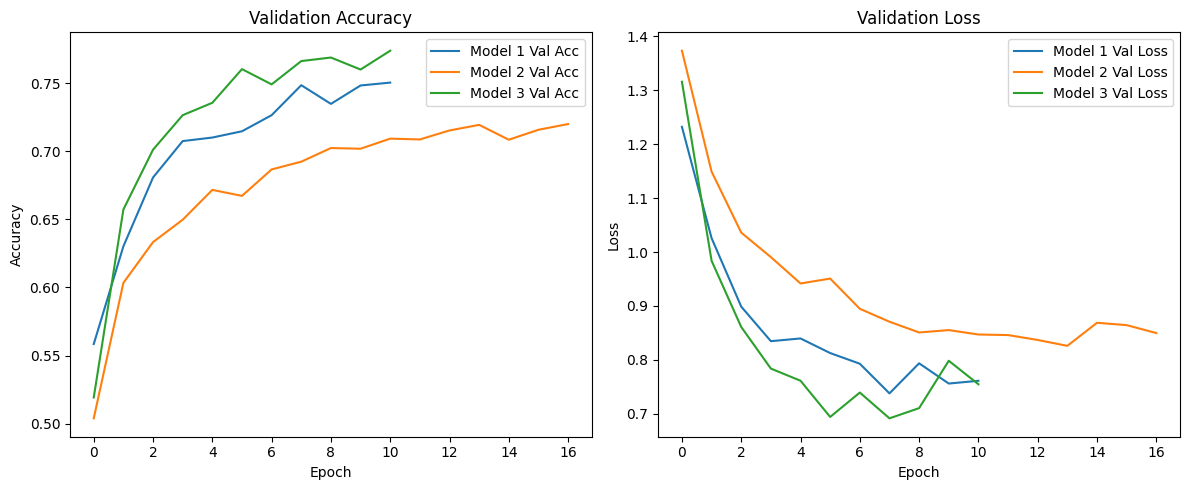

In [21]:
# Plot validation accuracy and loss for each model
def compare_histories(histories, labels):
    plt.figure(figsize=(12,5))

    # Accuracy comparison
    plt.subplot(1,2,1)
    for history, label in zip(histories, labels):
        plt.plot(history.history['val_accuracy'], label=f'{label} Val Acc')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss comparison
    plt.subplot(1,2,2)
    for history, label in zip(histories, labels):
        plt.plot(history.history['val_loss'], label=f'{label} Val Loss')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

compare_histories([history1, history2, history3], ['Model 1', 'Model 2', 'Model 3'])

In [22]:
# Get test accuracies
test_scores = {}
for model, label in zip([model1, model2, model3], ['Model 1', 'Model 2', 'Model 3']):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    test_scores[label] = acc
    print(f'{label} Test Accuracy: {acc:.4f}')

Model 1 Test Accuracy: 0.7414
Model 2 Test Accuracy: 0.7149
Model 3 Test Accuracy: 0.7666


### Final Evaluation and Predictions

The best model (Model 3) is tested on the test dataset. A classification report, confusion matrix, and example predictions are used to interpret performance.


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on test set using Model 3
y_pred = model3.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Classification Report
print("Classification Report for Model 3:\n")
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 3')
plt.show()

def predict_single_image(model, image_array, class_names):
    """
    Predicts and visualises a single image.
    """
    image = np.expand_dims(image_array, axis=0)
    prediction = model.predict(image)[0]
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.imshow(image_array)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

# Call the function like this (outside the function definition):
predict_single_image(model3, X_test[3], class_names)


NameError: name 'model3' is not defined

### Visualising Predictions

Five example images from the test set are shown alongside their predicted and true labels. Model confidence is displayed.


In [ ]:
def show_predictions(model, X_test, y_test, class_names):
    y_probs = model.predict(X_test[:5])
    y_preds = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_test[:5], axis=1)

    plt.figure(figsize=(12,5))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[i])
        plt.axis('off')
        plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_preds[i]]}\nConf: {y_probs[i][y_preds[i]]:.2f}")
    plt.show()

# Example usage
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
show_predictions(model3, X_test, y_test, class_names)
